<a href="https://colab.research.google.com/github/AnshulSingh-eZ/Deep-Learning/blob/main/1D_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muthuj7/weather-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'weather-dataset' dataset.
Path to dataset files: /kaggle/input/weather-dataset


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [42]:
path += "/weatherHistory.csv"
data = pd.read_csv(path)

In [43]:
len(data)

96453

In [44]:
data.duplicated().sum()

np.int64(24)

In [45]:
data = data.dropna()
data = data.drop_duplicates()
len(data)

95912

In [46]:
data.head(5)


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [47]:
set(data['Loud Cover'])

{0.0}

In [48]:
data = data.drop(['Formatted Date','Daily Summary','Summary', 'Precip Type', 'Loud Cover'], axis=1)
data.head()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13
1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63
2,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94
3,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41
4,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51


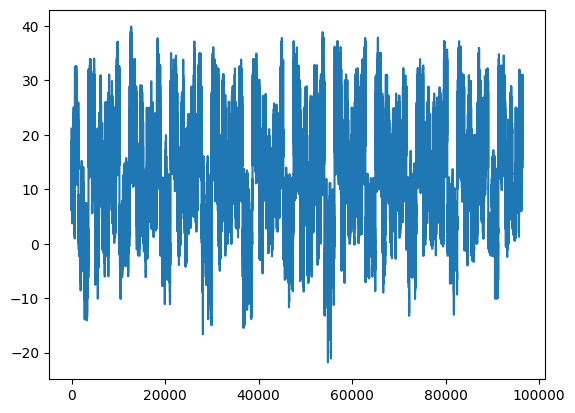

In [49]:
plt.plot(data['Temperature (C)'])
plt.show()
# plt.plot(data['Pressure (millibars)'], data['Humidity'])


In [161]:
import torch
import torch.nn as nn
class Simple1DCNN(nn.Module):
  def __init__(self):
    super(Simple1DCNN, self).__init__()
    self.conv1 = nn.Conv1d(in_channels=6, out_channels=32, kernel_size=3)
    self.relu = nn.ReLU()
    self.conv2 = nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3)
    self.fc = nn.Linear(16,1)
  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.relu(x)
    x = x[:,:,-1]
    logits = self.fc(x)
    # pred = torch.sigmoid(x)
    return logits

model = Simple1DCNN()

In [107]:
Y_dataset = data['Temperature (C)']
X_dataset = data.drop(columns=['Temperature (C)'])
X_dataset = torch.tensor(X_dataset.values, dtype=torch.float)
Y_dataset = torch.tensor(Y_dataset.values, dtype=torch.float).unsqueeze(1)

train_size = int(0.8*len(X_dataset))
X_train = X_dataset[:train_size]
X_test = X_dataset[train_size:]
Y_train = Y_dataset[:train_size]
Y_test = Y_dataset[train_size:]

In [108]:
len(X_train)

76729

In [109]:
from sklearn.preprocessing import StandardScaler
window = 23
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X = []
Y = []
X_train_scaled = x_scaler.fit_transform(X_train)
X_train_scaled = torch.tensor(X_train_scaled, dtype = torch.float)
Y_train_scaled = y_scaler.fit_transform(Y_train)
Y_train_scaled = torch.tensor(Y_train_scaled, dtype = torch.float)
for i in range(len(X_train_scaled) - window):
    X.append(X_train_scaled[i:i+window].T)
    Y.append(Y_train_scaled[i+window])

X = torch.stack(X)

Y = torch.stack(Y).unsqueeze(1)
print(X.dtype, Y.dtype)

torch.float32 torch.float32


In [110]:
print(max(Y), min(Y))
max(Y)-min(Y)
1/61
#1.6% expected loss - our buffering at 4, starts at 10+, some time need to squeeze the weights - scale the values (Pressure and windspeed might be overriding the weights)

tensor([[2.8919]]) tensor([[-3.4710]])


0.01639344262295082

In [111]:
from torch.utils.data import TensorDataset, DataLoader
dataset = TensorDataset(X, Y)

loader = DataLoader(dataset, batch_size=128, shuffle=False)

In [112]:
for x, y in loader:
  print(x.shape, y.shape)
  break

torch.Size([128, 6, 23]) torch.Size([128, 1, 1])


In [162]:
import torch.optim as optim
criteria = nn.L1Loss()
lossi = []
cnt = 0
epoch = 100
optimizer = optim.Adam(model.parameters(), lr=0.001)
for i in range(epoch):
  epoch_loss=0
  for x, y in loader:
    pred = model(x)
    loss = criteria(pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_loss+=loss.item()
  epoch_loss/=len(loader)
  lossi.append(epoch_loss)
  print(f'Epoch={i+1}, loss={epoch_loss}')
  cnt+=1


Epoch=1, loss=0.5395729244003693
Epoch=2, loss=0.49379716572662197
Epoch=3, loss=0.4897402422626813
Epoch=4, loss=0.487689704845349
Epoch=5, loss=0.4863414337982734
Epoch=6, loss=0.48523774651189644
Epoch=7, loss=0.484265195603172
Epoch=8, loss=0.4833319696038961
Epoch=9, loss=0.4825571486602227
Epoch=10, loss=0.4818989357352257
Epoch=11, loss=0.4812495075662931
Epoch=12, loss=0.4806536146750053
Epoch=13, loss=0.4801109331597884
Epoch=14, loss=0.4796626871575912
Epoch=15, loss=0.47926751335461937
Epoch=16, loss=0.47882299865285555
Epoch=17, loss=0.4784941523770491
Epoch=18, loss=0.47817742029825844
Epoch=19, loss=0.47789546409000955
Epoch=20, loss=0.4776344591627518
Epoch=21, loss=0.4773718833302458
Epoch=22, loss=0.47711830895394086
Epoch=23, loss=0.47686781962712604
Epoch=24, loss=0.47662644567588963
Epoch=25, loss=0.4763754661629597
Epoch=26, loss=0.4761793021361033
Epoch=27, loss=0.4760051888972521
Epoch=28, loss=0.4758305205653111
Epoch=29, loss=0.4756754411632816
Epoch=30, loss=0

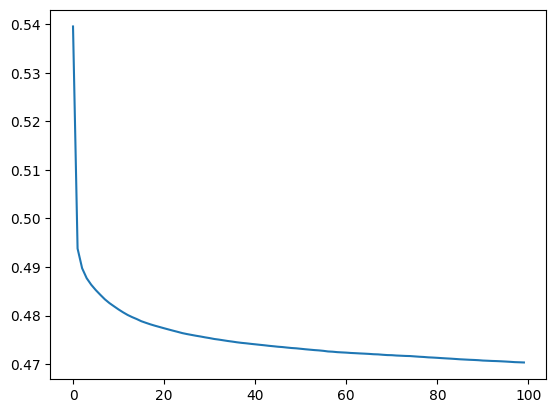

In [163]:
plt.plot(lossi)

In [164]:
print(min(Y_test), max(Y_test))

tensor([-13.0667]) tensor([37.1944])


In [165]:
X_test_scaled = x_scaler.transform(X_test)
Y_test_scaled = y_scaler.transform(Y_test)
X_test_scaled = torch.tensor(X_test_scaled, dtype = torch.float)
Y_test_scaled = torch.tensor(Y_test_scaled, dtype = torch.float)

In [166]:
window = 23
Xt = []
Yt = []
for i in range(len(X_test_scaled) - window):
    Xt.append(X_test_scaled[i:i+window].T)
    Yt.append(Y_test_scaled[i+window])

Xt = torch.stack(Xt)
Yt = torch.stack(Yt).unsqueeze(1)

In [167]:
print(Xt.shape, Yt.shape)

torch.Size([19160, 6, 23]) torch.Size([19160, 1, 1])


In [168]:
model.eval()
with torch.no_grad():
  pred_scaled = model(Xt)



In [169]:
pred_scaled.shape

torch.Size([19160, 1])

In [170]:
pred = y_scaler.inverse_transform(pred_scaled.cpu().numpy())

In [171]:
Yt.shape

torch.Size([19160, 1, 1])

In [172]:
y_true = y_scaler.inverse_transform(Yt.squeeze(1).cpu().numpy())

In [173]:
y_true.shape

(19160, 1)

In [174]:
pred.shape

(19160, 1)

In [175]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_true, pred)
print(mae)

2.9106171131134033


In [155]:
sz = len(y_true)

In [177]:
mae_24_baseline = mean_absolute_error(y_true[23:], y_true[:-23])
print(mae_24_baseline)

3.0357017517089844
